# An Encoder–Decoder Network for Neural Machine Translation

---



This notebook develops a traditional encoder-decoder translation model. It is a fork of the Auerlion Geron notebook found at https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb

But this version has been updated to comply with Keras 3, namely by implementing cusom loss and accuracy functions to accomodate masked output vectors.

Author: Patrick White

In [3]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2025-03-26 14:27:44.806304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743013664.893101    2031 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743013664.914383    2031 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743013665.265178    2031 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743013665.265211    2031 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743013665.265212    2031 computation_placer.cc:177] computation placer alr

In [4]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

In [6]:
## Download the spanish/english dataset

url = "https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
path = tf.keras.utils.get_file("spa-eng.zip", origin="file:///home/arush/ML/data/spa-eng.zip", extract=True)


from pathlib import Path
# The file might be extracted to a subdirectory within ~/.keras/datasets
# Search for 'spa.txt' in subdirectories:
dataset_path = Path(path).parent
for file_path in dataset_path.rglob('spa.txt'):
    if file_path.is_file():
        dataset_path = file_path
        break

text = dataset_path.read_text()

Exception: URL fetch failure on file:///home/arush/ML/data/spa-eng.zip: None -- [Errno 2] No such file or directory: '/home/arush/ML/data/spa-eng.zip'

In [ ]:
import numpy as np

# preprocess -- note how the lines are split up and shuffled and zipped together in pairs

text = text.replace("¡", "").replace("¿", "")
pairs = [line.split("\t") for line in text.splitlines()]
np.random.shuffle(pairs)
sentences_english, sentences_spanish = zip(*pairs)  # separates the pairs into 2 lists

In [ ]:
for i in range(3):
    print(sentences_english[i], "=>", sentences_spanish[i])

She sleeps on her back. => Ella duerme de costado.
There's a theory that dog owners often resemble their dogs. => Hay una teoría que dice que los dueños usualmente se parecen a sus perros.
I lived overseas for ten years. => Viví en el extranjero durante diez años.


In [ ]:
vocab_size = 10000 # the size of our language vocab
max_length = 50 # max sentence length. shorter might train faster

# Now you will create layers to vectorize sentences into lists of arrays.
# Instead of preprocessing the sentences once, we create this as a layer in the model
# So the model input can be a text string.

# Do this: create a keras TextVectorization layer, layer_english_vectorization,  using the above parameters
# then call .adapt on that layer, passing in the english sentences as parameter

###################### CODE HERE #################

# now do the same with the spanish -- make and adapt a layer
# BUT for the spanish add 'starttoken' and 'endtoken' to each sentence first


###################### CODE HERE #################

In [ ]:
# this will show the top 10 tokens
layer_english_vectorization.get_vocabulary()[:10]

In [ ]:
# and the same for spanish
layer_spanish_vectorization.get_vocabulary()[:10]

In [ ]:
# In this cell define
# X_train_encoder, X_valid_decoder, X_train_decoder_X_valid_decoder, Y_train and Y_valid

# X_train_encoder is the first 100,000 english sentences, conveted to tf.constant (input to the encoder layer)
# X_valid_encoder is the remainder

# X_train_decoder is the first 100,000 spanish sentences, with START token added only (input to the decoder layer)
# X_valid_decoder is similar

# the above are the INPUT sentences to the encoder and decoder

# Y_train are the corresponsing spanish sentences with END token added only. Pass it to the appropriate vectorization layer
# same with Y_valid
# Note Y_train is not one-hot-encoded BUT it is vectorized. Each Y-train entry is a vector of size 50 (or different if you changed the parameters)

###################### CODE HERE #################

In [ ]:
# This should print 4 strings and 2 arrays. Check for appropriate tokens

print(X_train_encoder[0:1].numpy()[0].decode())
print(X_valid_encoder[0:1].numpy()[0].decode())
print(X_train_decoder[0:1].numpy()[0].decode())
print(X_valid_decoder[0:1].numpy()[0].decode())
print(Y_train[0:1].numpy())
print(Y_valid[0:1].numpy())

How boring!
I'm running out of ideas.
starttoken Qué aburrimiento!
starttoken Me estoy quedando sin ideas.
[[  25 5483    3    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]
[[  14   37 2285  141 1376    3    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]


In [ ]:
# Create encoder_input_layer and decoder_input_layer
# These are keras input layers with shape = [], type = tf.string and appropriately named

###################### CODE HERE #################

In [ ]:
# Change this or leave it -- its the vector embedding dimension
embed_size = 512

# define encoder_vectors as the english vectorization layer applied to the encoder input layer
###################### CODE HERE #################

# define decoder vectors
###################### CODE HERE #################

# define an encoder_embedding_layer as a keras Embedding layer, with mask_zero = True
###################### CODE HERE #################

# define an decoder_encoder_embedding_layer as a keras Embedding layer, with mask_zero = True

###################### CODE HERE #################

# finally define encoder_embeddings and decoder_embeddings as the output of the embedding layers applied to the vectors
###################### CODE HERE #################


In [ ]:
# don't change but read carefully!!
encoder_lstm = tf.keras.layers.LSTM(512, return_state=True, dropout=0.2, name = "Encoder_LSTM")
encoder_outputs, *encoder_state = encoder_lstm(encoder_embeddings)

In [ ]:
# don't change but read carefully!!
decoder_lstm = tf.keras.layers.LSTM(512, return_sequences=True, dropout=0.2, name = "Decoder_LSTM")
decoder_outputs = decoder_lstm(decoder_embeddings, initial_state=encoder_state)

In [ ]:
# create a Dense output_layer of the appropriate size for the spanish vocabulary

###################### CODE HERE #################

# create a dropout_layer
###################### CODE HERE #################

# define Y_proba. take the decoder_outputs through the dropout layer and into the dense layer
###################### CODE HERE #################


In [ ]:
# We need a custom loss function to deal with the zero padding

class MaskedSparseCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, from_logits=False, name="masked_sparse_categorical_crossentropy"):
        super().__init__(reduction="none", name=name)
        self.from_logits = from_logits

    @tf.function  # Compiles into a TensorFlow graph for speed
    def call(self, y_true, y_pred):
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=self.from_logits)
        mask = tf.cast(y_true != 0, dtype=tf.float32)  # Ignore padding (0 tokens)

        loss *= mask  # Apply mask
        loss_per_sequence = tf.reduce_sum(loss, axis=-1) / tf.maximum(tf.reduce_sum(mask, axis=-1), 1.0)

        return tf.reduce_mean(loss_per_sequence)  # Average over batch


In [ ]:
# We need a custom accuracy function to deal with the zero padding

class MaskedSparseCategoricalAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name="masked_sparse_categorical_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct_predictions = self.add_weight(name="correct", initializer="zeros")
        self.total_valid = self.add_weight(name="total", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Compute predicted class (argmax for probabilities or logit inputs)
        y_pred_classes = tf.argmax(y_pred, axis=-1, output_type=tf.int64)

        # Create mask where y_true != 0 (ignoring zero values)
        mask = tf.cast(y_true != 0, dtype=tf.float32)

        # Compare predictions with ground truth
        correct = tf.cast(tf.equal(y_true, y_pred_classes), dtype=tf.float32)

        # Apply mask
        correct *= mask

        # Update total count
        self.correct_predictions.assign_add(tf.reduce_sum(correct))
        self.total_valid.assign_add(tf.reduce_sum(mask))

    def result(self):
        return self.correct_predictions / tf.maximum(self.total_valid, 1.0)  # Avoid division by zero

    def reset_state(self):
        self.correct_predictions.assign(0)
        self.total_valid.assign(0)


In [ ]:
# A handy saving and stopping callback. Please update the save path!

class SaveBestModelWithEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, save_path="best_model.keras", patience=5):
        """
        Custom callback to:
        - Save the best model based on val_loss
        - Stop training if val_loss doesn't improve for 'patience' epochs

        Args:
            save_path (str): Path to save the best model.
            patience (int): Number of epochs to wait before stopping training if no improvement.
        """
        super().__init__()
        self.save_path = save_path
        self.patience = patience
        self.best_val_loss = float("inf")  # Initialize with a large value
        self.wait = 0  # Counter for patience

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss")

        if val_loss is not None:
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.model.save(self.save_path)  # Save the entire model
                print(f"\nEpoch {epoch+1}: val_loss improved to {val_loss:.4f}. Model saved to {self.save_path}")
                self.wait = 0  # Reset patience counter
            else:
                self.wait += 1  # No improvement, increase patience counter
                print(f"\nEpoch {epoch+1}: val_loss did not improve. Patience: {self.wait}/{self.patience}")

            # Stop training if patience limit is reached
            if self.wait >= self.patience:
                print(f"\nEarly stopping triggered! No improvement for {self.patience} epochs.")
                self.model.stop_training = True

#############################################################
#################### change the save path ###################
#############################################################
save_best_early_stop = SaveBestModelWithEarlyStopping(save_path="snapshots/translator_A.keras", patience=2)

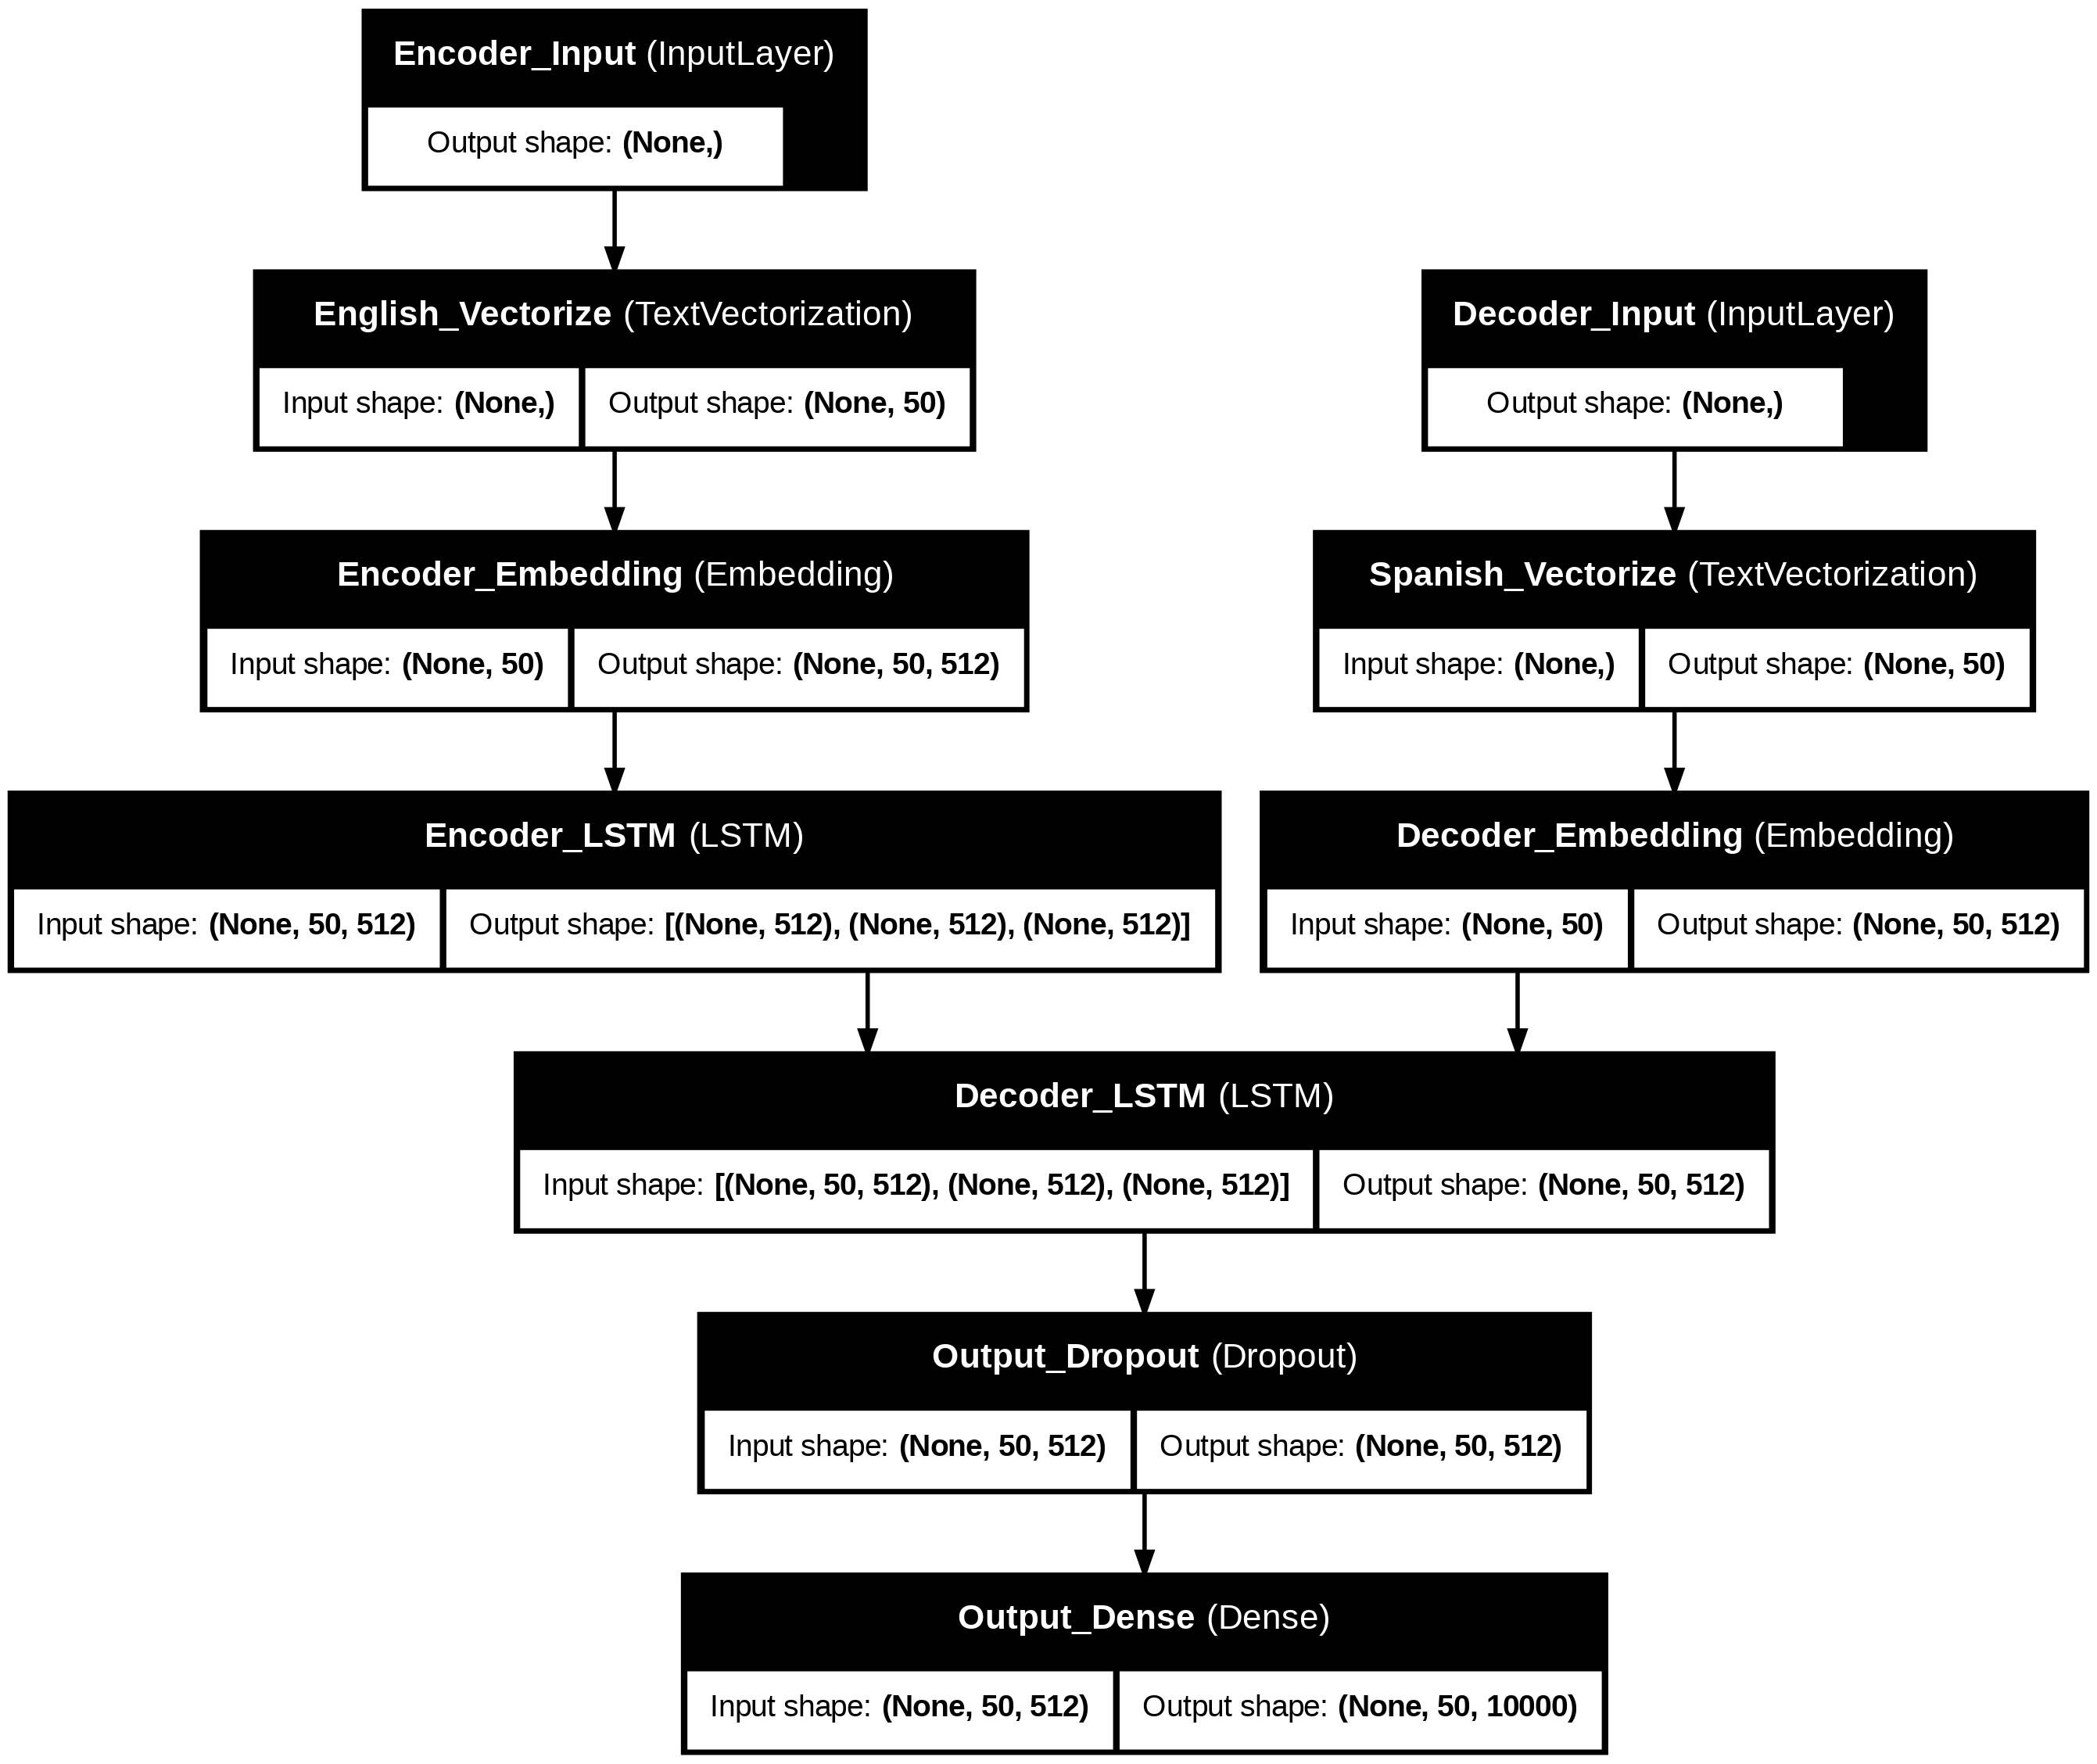

In [ ]:
from tensorflow.keras.utils import plot_model

### BUILDING THE MODEL #####

### fill in the inputs as a list of the encoder and decoder inputs
#### fill in the outputs as a list containing the single output layer

model_A = tf.keras.Model(inputs= ############ ,
                       outputs=##################)

# fill in the right loss and metrics and callbacks
model_A.compile(##########################)


# Plot the model architecture
plot_model(model_A, to_file='model_A_architecture.png', show_shapes=True, show_layer_names=True)

In [ ]:

# FIT the model. Accuracy will be in the 40-50 range probably. More epochs will increase it

model_A.fit((X_train_encoder, X_train_decoder), Y_train, epochs=3,
          validation_data=((X_valid_encoder, X_valid_decoder), Y_valid),
         callbacks = [save_best_early_stop])

Epoch 1/3
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7646 - masked_sparse_categorical_accuracy: 0.1923
Epoch 1: val_loss improved to 0.5764. Model saved to snapshots/translator_A.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - loss: 0.7644 - masked_sparse_categorical_accuracy: 0.1924 - val_loss: 0.5764 - val_masked_sparse_categorical_accuracy: 0.3069
Epoch 2/3
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5479 - masked_sparse_categorical_accuracy: 0.3307
Epoch 2: val_loss improved to 0.4499. Model saved to snapshots/translator_A.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - loss: 0.5479 - masked_sparse_categorical_accuracy: 0.3307 - val_loss: 0.4499 - val_masked_sparse_categorical_accuracy: 0.4151
Epoch 3/3
1231/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.4358 - masked_sparse_categorical_accuracy: 0.4182

In [ ]:
## a method to translate sentences

def translate(a_model, sentence_en):
    translation = ""
    for word_idx in range(max_length):
        X =  tf.convert_to_tensor([sentence_en])  # encoder input
        X_dec = tf.convert_to_tensor(["starttoken " + translation])
        y_proba = a_model.predict((X, X_dec))[0, word_idx]  # last token's probas
        predicted_word_id = np.argmax(y_proba)
        predicted_word = layer_spanish_vectorization.get_vocabulary()[predicted_word_id]
        if predicted_word == "endtoken":
            break
        translation += " " + predicted_word
    return translation.strip()

In [ ]:
translate(model_A, "I like soccer")

Nice! However, the model struggles with longer sentences:

In [ ]:
translate(model_A, "I like soccer and also going to the beach")

In [ ]:
translate(model_A, "When I fell before the game I broke my leg")

## Bidirectional RNNs

To create a bidirectional recurrent layer, just wrap a regular recurrent layer in a `Bidirectional` layer:

In [ ]:
encoder = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_state=True))

In [ ]:
from tensorflow.keras.layers import Lambda

encoder_outputs, *encoder_state = encoder(encoder_embeddings)

# We have to split the outputs up into two because the Bidirectional layer has twice as many.
# Use a Lambda layer to handle the concatenation
def concatenate_states(states):
    short_term = tf.concat(states[::2], axis=-1)  # short-term (0 & 2)
    long_term = tf.concat(states[1::2], axis=-1)   # long-term (1 & 3)
    return [short_term, long_term]

# Apply the Lambda layer to the encoder state
encoder_state = Lambda(concatenate_states)(encoder_state)

**Warning**: the following cell will take a while to run (possibly a couple hours if you are not using a GPU).

In [ ]:
# extra code — completes the model and trains it
decoder = tf.keras.layers.LSTM(512, return_sequences=True)
decoder_outputs = decoder(decoder_embeddings, initial_state=encoder_state)
output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")
Y_proba = output_layer(decoder_outputs)
save_best_early_stop = SaveBestModelWithEarlyStopping(save_path="snapshots/translator_B.keras", patience=2)

model_B = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs],
                       outputs=[Y_proba])
model_B.compile(loss=MaskedSparseCategoricalCrossentropy(from_logits=False), optimizer="nadam",
              metrics=[MaskedSparseCategoricalAccuracy()])
model_B.fit((X_train, X_train_dec), Y_train, epochs=6, batch_size=64,
          validation_data=((X_valid, X_valid_dec), Y_valid),
           callbacks = [save_best_early_stop])

In [ ]:
translate(model_B, "I like soccer")

In [ ]:
translate(model_B, "I like soccer and also going to the beach")

In [ ]:
translate(model_B, "When I fell on the football field I broke my leg")